## **SUMMARY**
This script is used to preprocess local address and parcel data to be merged to create a footprint-level building inventory.

In [1]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [2]:
# Relevant python functions
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import folium 
import os
import sys

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)

import functions_general as fxns

In [3]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

In [4]:
## Create folder for preprocessed data 
directory = './Input_Data/ProcessedData/Local/'
os.makedirs(directory, exist_ok=True)

## **Load Footprint and Census Data**

In [5]:
# Select Footprint Source
footprint_path = './Input_Data/ProcessedFootprints/Hayward_Footprints.json'
footprints = gpd.read_file(footprint_path)
footprints.to_crs(crs_main, inplace = True)
footprints['FootprintID'] = footprints['FootprintID'].astype('Int64')

In [6]:
# Load census boundaries

# Load Census blocks and tracts (generated in preprocessing file)
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2010/Hayward_blocks.geojson')
hayward_tracts = gpd.read_file('./Input_Data/Census/Census2010/Hayward_tracts.geojson')

geoid = 'GEOID10'  # Census 2010 GEOID field name

## **Preprocess Address Data**

In [7]:
# Load address data downloaded from Hayward GIS
points = gpd.read_file('./Input_Data/Local/Hayward_Addresses.geojson')
points = points.to_crs(epsg=crs_main)

### **Remove exact duplicates**

In [8]:
### CLEAN ADDRESS DATA AND PREPARE FOR MERGE WITH SCRAPED DATA ###

# Remove exact duplicates from hayward res data 
print('All Hayward Address Points:',len(points))
points = points.drop_duplicates() # Remove exact duplicates
print('After exact duplicates:',len(points))

All Hayward Address Points: 82047
After exact duplicates: 82047


### **Trim to study boundaries**

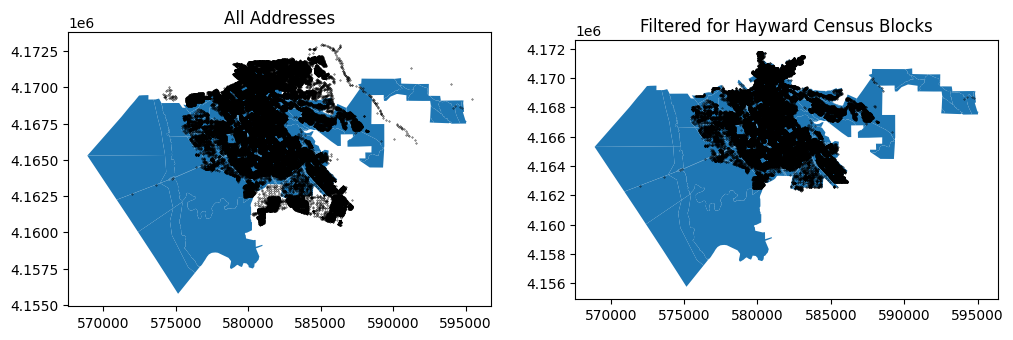

In [9]:
# Trim to study boundaries 

# Plot
fig, ax = plt.subplots(1,2, figsize = (12, 12))
hayward_blocks.plot(ax=ax[0])
points.plot(ax=ax[0], color ='black', markersize = 0.1)
ax[0].set_title('All Addresses')

# Assign block to addresses
points_copy = points.copy()
points_copy = points_copy.sjoin(hayward_blocks, how='left')
points.loc[:, 'CensusBlock'] = points_copy[geoid].values

# Assign tract to addresses
points_copy = points.copy()
points_copy = points_copy.sjoin(hayward_tracts, how='left')
points.loc[:, 'CensusTract'] = points_copy[geoid].values

# Drop rows that are not in blocks of interest (Hayward)
points = points[~points['CensusBlock'].isna()].copy()

# Plot to check 
hayward_blocks.plot(ax=ax[1])
points.plot(ax=ax[1], color ='black', markersize = 0.1)
ax[1].set_title('Filtered for Hayward Census Blocks')
plt.show()

### **Map to to Hazus occupancy class ontology and drop relevant points**

In [10]:
# Map building feature codes to Hazus occupancy class values 

### CONVERT TO NSI ###

# NAICS CODES https://www.census.gov/naics/?input=22&chart=2022&details=221310

# NAICS Codes are based on business classification - not the same as building classification 

# Define map between Address Point Feature Code and NSI 
fc_map = {
    np.nan : None,
    'Single-Family Dwelling' : 'RES1', 
    'Single-Family Residential' : 'RES1',
    'Duplex' : 'RES3A',
    'Single Family Residence with addressed ADU': 'RES1',
    'Single-Family Dwelling Accessory Suite': 'RES1',
    'Multi-Family Lot, Single Family Residence': 'RES1',
    'Multi-Family Dwelling, Apartment':'RES3',
    'Triplex':'RES3B',
    'Multi-Family Dwelling':'RES3',
    'Multi-Family Residential':'RES3',
    'Multi-Family':'RES3',
    'Multi-Family Dwelling, Condominium':'RES3',
    'Fourplex':'RES3B',
    'Multi-Family Dwelling, Townhouse':'RES3',
    'Mobile Home Park': 'RES2',
    'Mobile / Modular / Manufactured Home': 'RES2',
    'Single Family Residence, Duet' : 'RES3A',
    'Institutional Residence / Dorm / Barracks': 'RES5',
    'Single Family Residence with non-addressed ADU':'RES3A',  
    'Single Family Residential - Converted from Only ADU' : 'RES1',
    'Airport Hangar' : 'COM4', # NAICS 488119 checked using Hazus document
    'Bank' : 'COM5',
    'Banking or Finance Facility' : 'COM5',
    'Building General' : 'UNK',
    'Building Shell' : 'UNK',
    'Business Park Office' : 'COM4',
    'Cellular Site' : 'NOTBLDG', #### DIVERGE: NAICS 237130 (Power and Communication Lines) is classified as IND6, which is why there may be buildings in the roads. I chose to leave this as 'NOTBLDG' in this case 
    'Cemetery' : 'NOTBLDG', #### DIVERGE: NAICS 812220 (Cemetaries and Crematories) classified as COM4. I chose to leave this as 'NOTBLDG' in this case 
    'Clubhouse / Community Building' : 'COM8',
    'College / University' : 'EDU2',
    'Commercial or Retail Facility' : 'COM1', 
    'Common Area' : 'NOTBLDG', 
    'Communication Tower' : 'NOTBLDG', # DIVERGE: NAICS 237130 (Power and Communication Lines) is classified as IND6, which is why there may be buildings in the roads. I chose to leave this as 'NOTBLDG' in this case 
    'Cooperative' : 'RES3', # There could be housing or business cooperatives, but assuming here it is a housing cooperative
    'County Government Facility' : 'GOV1',
    'Dairy' : 'AGR1',
    'Day Care Facility' : 'COM3', # NAICS 624410 checked using Hazus document 
    'Education Facility' : 'EDU1',
    'Electric Vehicle Charging Station' : 'NOTBLDG', # Didn't seem to have a clear NAICS code 
    'Electrical Meter' : 'NOTBLDG', # DIVERGE: NAICS 221122 (Electrical Power Distribution) is COM4, NAICS 334515 (Instrument Manufacturing for Electrical Signals) is IND2. I chose to leave thie as 'NOTBLDG' in this case
    'Energy Facility' : 'IND1',  # Depending on type of energy, NAICS codes designated as IND1 or IND2. Here, using IND1 
    'Fire Station / EMS Station' : 'GOV2', 
    'Fitness Center' : 'COM8', 
    'Gas Station': 'COM1', # NAICS 447110 checked using Hazus document
    'Gate' : 'NOTBLDG', 
    'Golf Course' : 'NOTBLDG', # DIVERGE: NAICS 713910 (Golf Courses and Country Clubs) classified as COM8. I chose to leave as 'NOTBLDG' in this case 
    'Government or Military Facility' : 'GOV1',
    'Greenhouse / Nursery' : 'AGR1',
    'Grocery Store': 'COM1',
    'Health or Medical Facility' : 'COM7',
    'Hospital / Medical Center' : 'COM6',
    'Hotel / Motel' : 'RES4',
    'House of Worship': 'REL1',
    'Industrial Business Park' : 'IND', # Insufficient specificity for more detailed designation 
    'Industrial Condominium': 'IND', # Insufficient specificity for more detailed designation 
    'Industrial Facility' : 'IND', # Insufficient specificity for more detailed designation 
    'Information or Communication Facility' : 'IND6', # NAICS 237130 checked using Hazus document 
    'Irrigation Controller' : 'COM4', # NAICS 221310 (Water Supply and Irrigation Systems) checked using Hazus document 
    'Library' :'GOV1', # DIVERGE: NAICS 519120 (Libraries and Archives) listed under COM4, but I thought it was more appropriate as a governemntal building 
    'Light Rail Station' : 'COM4', # 485112 (Commeter Rail Systems) checked using Hazus document 
    'Motor Vehicle Dealer' : 'COM1',
    'Motor Vehicle Repair' : 'COM3',
    'Municipal Government Facility' : 'GOV1',
    'Nursing Home / Long Term Care' : 'RES6',
    'Park' : 'NOTBLDG',
    'Parking Lot' : 'NOTBLDG', # DIVERGE: NAICS 812930 (Parking Lots and Garages) classified as COM3. I chose to leave as 'NOTBLDG' in this case
    'Post Office' : 'GOV1',
    'Public Attraction or Landmark Building' : 'GOV1',
    'Street Light':'NOTBLDG',
    'Public Pool' : 'NOTBLDG', # DIVERGE: NAICS 713940 (Fitness and recreational Sports Centers) listed under COM8. I chose to leave as 'NOTBLDG' in this case
    'Pump' : 'NOTBLDG', # DIVERGE: NAICS 333911 (Pump and Pumping Equipment Manufacturing) under IND1 and 221310 (Water Supply) under COM4. I chose to leave as 'NOTBLDG' in this case
    'Railroad Facility' : 'COM4',  # 485112 (Commeter Rail Systems) checked using Hazus document 
    'Railroad Maintenance / Fuel Facility' : 'COM4', # NAICS 488210 checked using Hazus document 
    'Recycling Facility' : 'COM4', # NAICS 562920 checked using Hazus document 
    'Restaurant / Eating Establishment' : 'COM1',
    'Rural / Open Space' : 'NOTBLDG',
    'School: Elementary' : 'EDU1',
    'Shopping Mall / Complex' : 'COM1',
    'State Government Facility' : 'GOV1',
    'Substation' : 'NOTBLDG', # Several possible NAICS codes, but chose to leave as 'NOTBLDG' in this case 
    'Telecom Utility Box' : 'NOTBLDG', # Several possible NAICS codes, but chose to leave as 'NOTBLDG' in this case 
    'Telephone Facility' : 'NOTBLDG', # Several possible NAICS codes, but chose to leave as 'NOTBLDG' in this case 
    'Traffic Signal' : 'NOTBLDG',
    'Transportation Facility' : 'COM4', # NAICS 488490 (Support Activiies for Road Transportation) checked using Hazus document 
    'Trucking Firm' : 'COM2', # NAICS 484110 (General Freight Trucking, Local) and 484121 (General Freight Trucking, Long-Distance) checked using Hazus document 
    'Vacant Land' : 'NOTBLDG',
    'Warehouse' : 'COM2', # NAICS 493110 (General Warehousing and Storage) checked using Hazus document 
    'Warehouse (Retail / Wholesale)' : 'COM2', # NAICS 493110 (General Warehousing and Storage) checked using Hazus document 
    'Water Meter' : 'NOTBLDG',
    'Water Tank' : 'NOTBLDG',
    'Water Treatment Facility' : 'GOV1', # DIVERGE: NAICS 221320 (Sewage Treatment Facilities) listed as COM4, may be more appropriate as GOV1? 
    'Emergency Response or Law Enforcement Facility':'GOV2',
    'Electric Facility': 'NOTBLDG',
    'Rehabilitation Center':'COM7',
    'Agriculture or Livestock Structure':'AGR1',
    'American Red Cross Facility':'COM7',
    'Private Water Supply Well': 'NOTBLDG',
    'Water Pumping Station':'NOTBLDG',
    'Mine':'NOTBLDG',
    'Fire Pump':'NOTBLDG',
    'Water Supply or Treatment Facility':'GOV1'
}


### CONVERT ADDRESS FEATURE CODE TO NSI ###
points['FC_Hazus'] = points['FeatureCode'].map(fc_map)


In [11]:
# Drop Addresses that are not Buildings (NOTBLDG)
print(len(points[points['FC_Hazus']=='NOTBLDG']), 'points labeled NOTBLDG')
points = points[points['FC_Hazus']!='NOTBLDG']
print(len(points), 'points for processing')

848 points labeled NOTBLDG
62364 points for processing


### **Drop unncessary columns**

In [12]:
### DROP COLUMNS THAT DO NOT NEED TO BE REATINED THROUGHOUT INVENTORY GENERATION ###
columns_to_drop = ['APN_GIS','Status','Affordability_Level','Affordable','Pre_Type','Zone','SitusAddress','OBJECTID',
                   'HouseNum', 'Prefix', 'Pre_Type','Street_Name', 'Street_Type', 'Suffix_Dir', 'House_Unit', 'City',
                    'State', 'Zipcode', 'Zone', 'FullAddress', 'AddrUnit_Type','SubtypeField','LonTxt_X','LatTxt_Y']
points = points.drop(columns=columns_to_drop)

### **Save address data for future use**

In [13]:
# Save
fxns.gdf_to_json(points, directory + 'Address_for_Merge.json')

JSON File Saved


## **Preprocess Parcel Data**

In [14]:
# Load extended parcel data from Hayward GIS 
extended_data = pd.read_csv('./Input_Data/Local/Additional_Parcel_Information.csv', low_memory=False)

### **Remove exact duplicates**

In [15]:
# Clean extended parcel data by removing duplicates - some parcels appear in twice in the databse, so keep more recent entry (last)
print('Extended data before removing duplicates:', len(extended_data))
extended_data = extended_data.drop_duplicates(subset=['APN_PQ'], keep='last')
print('Extended data after removing APN_PQ duplicates:', len(extended_data))

Extended data before removing duplicates: 39643
Extended data after removing APN_PQ duplicates: 37286


### **Remove unreasonable values**

In [16]:
# Remove extremely old houses (one row has eff year built of 1062 - seem like typos of "1062" instead of "1962")
drop_idx = extended_data[(extended_data['Eff_Year_Built']<1700) | (extended_data['Eff_Year_Built']>2026)].index
print(len(drop_idx))
extended_data.loc[drop_idx, 'Eff_Year_Built'] = np.nan
drop_idx = extended_data[(extended_data['Year_Built']<1700) | (extended_data['Year_Built']>2026)].index
print(len(drop_idx))
extended_data.loc[drop_idx, 'Year_Built'] = np.nan

# Remove cases in tax data where number of stories is listed as 0
extended_data.loc[extended_data[extended_data['Num_Stories'] == 0].index, 'Num_Stories'] = np.nan

# Correct tax data type of 1.4 stories
extended_data.loc[extended_data[extended_data['Num_Stories'] == 1.4].index, 'Num_Stories'] = 1.5


2
0


### **Map to to Hazus ontology**

In [17]:
## OCCUPANCY CLASS 

# Define map between Parcel Use Description and NSI 
# NOTE: _VAC indicates that the parcel is labeled as "planned" or "vacant"
use_map = {
    np.nan : None,
    'Townhouse - Planned Development, Common Area or use' : 'RES3_VAC', 
    'Assisted Living Apartments' : 'RES6', 
    'Vacant industrial land (may include misc. imps)' : 'IND_VAC',
    'Triplex; double or duplex with single family home' : 'RES3B', 
    'Condominium - townhouse, first sale' : 'RES3',
    'SFR - Planned Development Tract, Common Area or use' : 'RES1_VAC', 
    '3 units, lesser quality than 2300 or unknown legal' : 'RES3B',
    'Condominium - townhouse, common area' : 'RES3', 
    'Commercial repair garage' : 'COM3', 
    'Lodgehall and/or clubhouse' : 'COM8', 
    'Bank' : 'COM5', 
    'Residential property converted to 5 or more units' : 'RES3', 
    'Wrecking yards' : 'NOTBLDG',
    'Vacant apartment common area or use' : 'RES3_VAC',
    'Condominium - single residential living unit' : 'RES3',
    'National Chain Retailer' : 'COM1',
    'None' : None, 
    'Single Family Res - Duet Style, R&T 402.1' : 'RES3A', 
    'Parking garage' : 'COM3', # NAICS 812930 (Parking Lots and Garages) classified as COM3 using Hazus document 
    'Single family residential homes used as such' : 'RES1', 
    'Five or more single family res homes' : 'RES1', 
    'Five or more single family res home': 'RES1',
    'Other recreational activity, e.g. rinks, stadiums' : 'COM8', 
    'Single family residential home, R&T 402.1' : 'RES1', 
    'Nursing/Custodial Care Facility' : 'RES6', 
    'Four living units; e.g. fourplex or triplex w/SFR' : 'RES3B', 
    '2 units, SFR with detattched accessory dwelling unit' : 'RES3A',
    'Single-tenant Retail Store' : 'COM1', 
    'Condominium Common Area or use' : 'RES3', 
    'Townhouse - Planned Development, R&T 402.1' : 'RES3_VAC',
    'Four residential living units, R&T 402.1' : 'RES3B', 
    'Multiple-Res building of 5 or more units + commercial units' : 'RES3M', # Indicating mixed use
    'Exempt Public Agency' : 'GOV1', 
    'Condominium - townhouse, common area' : 'RES3', 
    'Two, three or four single family homes' : 'RES1', 
    'Single family res home with non-economic 2nd unit' : 'RES3A',
    'Restricted residential income property' : 'RES3',
    'Res property of 2,3 or 4 units with rooming house' : 'RES3B',
    'SFR - Planned Development Tract with Common Area' : 'RES1_VAC', 
    'Mobile home park parcel with improvements' : 'RES2', 
    'SFR - Planned Development Tract, R&T 402.1' : 'RES1_VAC',
    'One to five story office building' : 'COM4', 
    'Improved rural-residential homesite.' : 'RES1',
    'Condominium - Townhouse R&T 402.1' : 'RES3',
    'Condominium-industrial, common area or use' : 'IND', # Insufficient specificity for more detailed designation 
    'Vacant apartment land, capable of 5 or more units' : 'RES3_VAC', 
    'Store/Office with Apts/Lofts' : 'RES3M', # Indicating mixed use
    'Condominium - single res unit, R&T 402.1': 'RES3',
    'Multi-Res building of 5 or more units R&T 402.1 + commercial': 'RES3M', # Indicating mixed use
    '2 units, SFR with attached accessory dwelling unit' : 'RES3A',
    '2 units, SFR with attached accessory dwelling unit, R&T 402.1' : 'RES3A', 
    'Single Family Res - Duet Style' : 'RES3A', 
    'Medical-Residential Care Facility (SFR/Res Imps)' : 'RES6', 
    'Church' : 'REL1', 
    'Single Family Res home with slight commercial/ind' : 'RES1', 
    'Vacant residential tract lot' : 'RES_VAC', 
    'Rural property in transition to a higher use' : 'UNK',
    'Single family modular built off site' : 'RES2', 
    'SFR with junior accessory dwelling unit' : 'RES3A', 
    'Vacant rural-res homesites, may incl misc. imps' : 'RES_VAC',  
    'Miscellaneous improved commercial' : 'COM', # Insufficient specificity for more detailed designation 
    'Duet/Duplex/Triplex - Planned Development Tract w/Common Area' : 'RES3B_VAC', 
    'Condominium-industrial' : 'IND', # Insufficient specificity for more detailed designation 
    'SFR Detached Site Condominium , Common Area or use' : 'RES1', 
    'More than 1 mobile home, or M/H w/other res units' : 'RES2', 
    'Double or duplex type - two units' : 'RES3A', 
    'Historical commercial' : 'COM1', 
    'Multiple residential building of 5 or more units.' : 'RES3',
    'Vacant residential land, zoned 4 units or less' : 'RES3B_VAC',
    'Condominium - townhouse style' : 'RES3', 
    'Fraternities and sororities' : 'RES5', # No explicit NAICS for frats, so classified here as dorms 
    'Residential Imps on Industrial Land' : 'RES_VAC', 
    '4 units, lesser quality than 2400 or unknown legal' : 'RES3B',
    'Rural property used for agriculture, 10+ acres' : 'AGR1', 
    'SFR - Manufactured Home (MH on permanent foundation)' : 'RES2', 
    'Service Stations' : 'COM1', # NAICS 447110 checked using Hazus document
    'Warehouse' : 'COM2', # NAICS 493110 (General Warehousing and Storage) checked using Hazus document 
    'Non-Condo Live/Work' : 'RES3M',  
    '2 units, lesser quality than 2200 or unknown legal' : 'RES3B',
    '2 units, SFR with detached accessory dwelling unit, R&T 402.1' : 'RES3A', 
    '\t2 units, SFR with detached accessory dwelling unit, R&T 402.1' : 'RES3A', 
    'SFR Detached Site Condominium' : 'RES1', 
    'Townhouse - Planned Development' : 'RES3_VAC', 
    '\tCondominium - single residential living unit': 'RES3', 
    '\tCondominium - townhouse, common area' : 'RES3', 
    'Vacant commercial land (may include misc. imps)' : 'COM_VAC',
    'Single family residential (tract) common area or use' : 'RES1',
    'Golf course' : 'NOTBLDG', # DIVERGE: NAICS 713910 (Golf Courses and Country Clubs) classified as COM8. I chose to leave as 'NOTBLDG' in this case 
    'Automobile dealership' : 'COM1', # NAICS 441110 checkecd against Hazus
    'Bank' : 'COM5',
    'Bowling alley' : 'COM8',
    'Car wash' : 'NOTBLDG', #### DIVERGE: NAICS 811192 (Car Washes) classified as COM3. I chose to leave this as 'NOTBLDG' in this case 
    'Cemetery' : 'NOTBLDG', #### DIVERGE: NAICS 812220 (Cemetaries and Crematories) classified as COM4. I chose to leave this as 'NOTBLDG' in this case 
    'Church' : 'REL1',
    'Commercial Imps on Residential Land' : 'RES3M',
    'Condominium - urban res unit above, common area or use' : 'RES3M', 
    'Condominium-commercial retail' : 'COM1', 
    'Condominium-commercial retail, common area or use' : 'COM1',
    'Condominium-office' : 'COM4',
    'Cooperatives (divided)' : 'RES3', # There could be housing or business cooperatives, but assuming here it is a housing cooperative
    'Data Center' : 'IND5',
    'Exempt Public Agency' : 'GOV1',
    'Fitness Center/Health Club/Gym' : 'COM8',
    'Funeral home' : 'COM3', # NAICS 812210 chekced using Hazus document  
    'Heavy industrial' : 'IND1',
    'Historical commercial' : 'COM1',
    'Hospital (general)' : 'COM6',
    'Industrial Flex/R&D' : 'IND2',
    'Industrial Light/Manufacturing' : 'IND2',
    'Lodgehall and/or clubhouse'  : 'COM8',
    'Medical - Dental building'  : 'COM7',
    'Misc. industrial (improved); no other ind code'  : 'IND', # Insufficient specificity for more detailed designation 
    'Miscellaneous improved commercial' : 'COM1',
    'Motel' : 'RES4',
    'National Chain Retailer' : 'COM1',
    'Non-Condo Live/Work' : 'RES3M',
    'Nursing/Custodial Care Facility' : 'RES6',
    'One to five story office building' : 'COM4',
    'Other institutional property' : 'GOV1', # Commonly used for community or public servies purposes, so assumed GOV1 was most appropriate 
    'Other recreational activity, e.g. rinks, stadiums' : 'COM8',
    'Over five story office building' : 'COM4',
    'Parking lot' : 'NOTBLDG',
    'Property leased to a public utility' : 'GOV1',
    'Property owned by a public utility' : 'GOV1',
    'Res property of 2,3 or 4 units with rooming house' : 'RES3',
    'Residential Imps on Commercial Land' : 'RES3M', 
    'Residential Imps on Industrial Land' : 'RES3M',
    'Restaurant - Fast Food' : 'COM8', # NAICS 722513 checked against Hazus document 
    'Restaurant - small or in-line walk-in restaurant / cafe' : 'COM8', # NAICS 722513 checked against Hazus document 
    'Restricted residential income property' : 'RES3', 
    'Rural property in transition to a higher use' : 'NOTBLDG',
    'Rural property used for agriculture, 10+ acres' : 'NOTBLDG',
    'School' : 'EDU1',
    'Shopping Center-NBHD without anchor (strip mall)' : 'COM1',
    'Shopping Center-NBHD/Grocery or Retail anchor' : 'COM1',
    'Shopping Center-Regional Mall' : 'COM1',
    'Single-tenant Retail Store' : 'COM1',
    'Skilled Nursing Facility' : 'COM7',
    'Store/Office with Apts/Lofts' : 'RES3M',
    'Supermarket' : 'COM1',
    'Terminals, trucking and distribution' : 'COM2', # NAICS 484110 (General Freight Trucking, Local) and 484121 (General Freight Trucking, Long-Distance) checked using Hazus document 
    'Vacant apartment land, R&T 402.1' : 'RES3_VAC',
    'Vacant apartment land, capable of 5 or more units' : 'RES3_VAC',
    'Vacant commercial land (may include misc. imps)' : 'COM_VAC',
    'Vacant residential land, zoned 4 units or less' : 'RES3_VAC',
    'Vacant residential tract lot' : 'RES3_VAC',
    'Vacant rural land, not usable even for agriculture' : 'NOTBLDG',
    'Rural property with significant commercial use':'COM',
    'Veterinarian Office' : 'COM1',
    'Warehouse-Cold Storage' : 'COM2', # NAICS 493120 checked against Hazus docuemnt 
    'Warehouse-Self Storage' : 'COM4', # NAICS 531130 chekced against Hazus document 
}


### CONVERT PARCEL USE DESCRIPTION TO NSI ###
extended_data['Use_Description_Hazus'] = extended_data['Use_Description'].map(use_map)

### Drop rows withnouse description ###
extended_data = extended_data[extended_data['Use_Description_Hazus'].notna()]

In [18]:
## BUILDING TYPE 

# Map tax building types to standard Hazus types 
construction_map = {
    'Wood': 'W', 
    'Masonry': 'M',
    'Concrete': 'C',
    'None': np.nan,  
    'Steel/Heavy': 'S',
    'S': 'S', # Many RES2 labeled with this, but also IND buildings with sheet metal siding. Assume these are steel buildings (RES2 gets relabeled)
    'W': np.nan, # This represents 3 GOV1 buildings, unknown what this represents 
    'M': np.nan, # Unknown, but only appears a few times 
    '7': np.nan, # Unknown, but only appears a few times 
    '5': np.nan, # Unknown, but only appears a few times 
    '4': np.nan, # Unknown, but only appears once
    'G': np.nan, # Unknown, but only appears a few times 
}

# Map construction types
extended_data['Construction_Hazus'] = extended_data['Construction'].map(construction_map)


### **Clean parcel geometry**

In [19]:
# Load parcel data and Census blocks 
parcels = gpd.read_file('./Input_Data/Local/Hayward_Parcels.geojson')
parcels = parcels.to_crs(epsg=crs_main)


# Drop columns that will not be used 
parcels = parcels.drop(columns=['APN_ACA', 'OBJECTID', 'APN_GIS', 'APN_BK_PG',
                                'OWNERCENSORED', 'P_HouseNum', 'P_Prefix', 'P_Pre_Type',
                                'P_Street_Name', 'P_Street_Type', 'P_Suffix_Dir', 'P_House_Unit',
                                'P_City', 'P_State', 'P_Zipcode', 'P_AREA', 'P_ST_ADDRESS',
                                'M_ST_ADDRESS', 'M_CITY', 'M_STATE', 'M_ZIP_FULL', 'TAXRATEAREA'])


# Remove duplicates and merge geometries for each APN
print(len(parcels))
duplicates = parcels[parcels.duplicated(subset=['APN_PQ'])]
dissolved = duplicates.dissolve(by='APN_PQ', as_index=False)
gdf_cleaned = parcels.drop_duplicates(subset='APN_PQ', keep='first')
gdf_cleaned = gdf_cleaned.set_index('APN_PQ')
dissolved = dissolved.set_index('APN_PQ')
gdf_cleaned.update(dissolved)
parcels_clean = gdf_cleaned.reset_index()
print(len(parcels_clean))


68373
67907


### **Trim parcels to study area**

40191 parcels after spatial join with census blocks


Text(0.5, 1.0, 'Parcels intersecting Hayward Census Blocks')

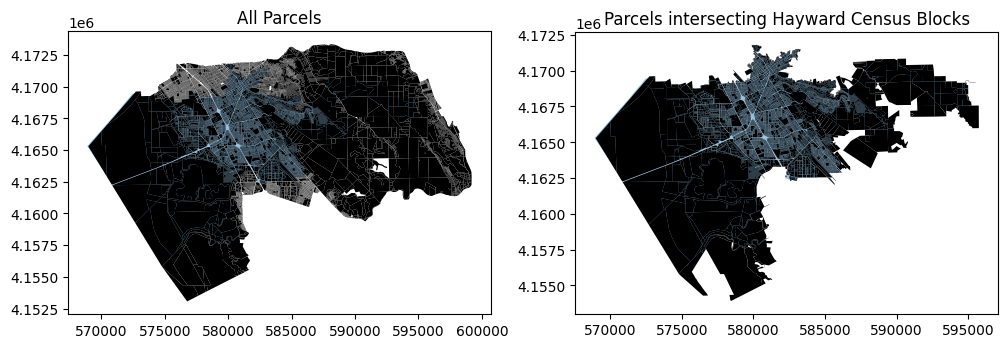

In [20]:
# Spatial join: keep only parcels that intersect anything in other_gdf
parcels_intersect = gpd.sjoin(parcels_clean, hayward_blocks, how="inner", predicate="intersects")
parcels_intersect = parcels_intersect[parcels_clean.columns]

# Drop duplicates due to spatial join
parcels_intersect = parcels_intersect.drop_duplicates(subset=['APN_PQ'])
print(len(parcels_intersect), 'parcels after spatial join with census blocks')

# Plot
fig, ax = plt.subplots(1, 2, figsize = (12, 12))
hayward_blocks.plot(ax=ax[0], alpha = 0.5)
parcels_clean.plot(ax=ax[0], color = 'black')
hayward_blocks.plot(ax=ax[1], alpha = 0.5)
parcels_intersect.plot(ax=ax[1], color = 'black')
ax[0].set_title('All Parcels')
ax[1].set_title('Parcels intersecting Hayward Census Blocks')

### **Link extended parccel data with parcel geometries**

37282


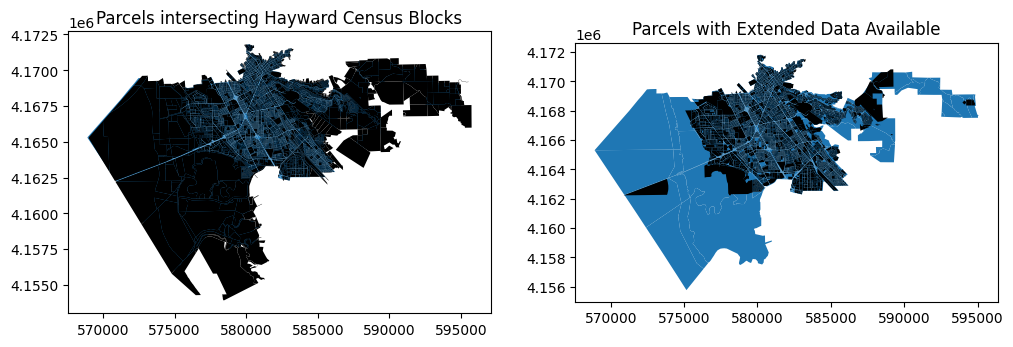

In [21]:
# Merge extended parcel data with parcel geometries -- effectively imposing boundaries becuase extended_data only available for Hayward boundaries
parcels_ext = parcels_intersect.merge(extended_data, on='APN_PQ', how='right')
print(len(parcels_ext))

#  Plot to show how parcels are trimmed to Hayward boundaries
fig, ax = plt.subplots(1,2, figsize = (12, 12))
hayward_blocks.plot(ax=ax[0])
parcels_intersect.plot(ax=ax[0], color ='black', markersize = 0.1)
ax[0].set_title('Parcels intersecting Hayward Census Blocks')
hayward_blocks.plot(ax=ax[1])
parcels_ext.plot(ax=ax[1], color ='black', markersize = 0.1)
ax[1].set_title('Parcels with Extended Data Available')
plt.show()

### **Save data for future use**

In [22]:
# Save cleanded parcel data
fxns.gdf_to_json(parcels_intersect, directory + 'Parcels.json')

# Save linked parcels and extended metadata
fxns.gdf_to_json(parcels_ext, directory + 'Parcels_with_Extended_Data.json')

JSON File Saved
JSON File Saved
